### Libraries & Setup

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from torchvision import transforms
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Load & Pre-Process

In [13]:
class RetinaData(Dataset):
  def __init__(self, dir_image, dir_mask, transform=None):
    self.dir_image = dir_image
    self.dir_mask = dir_mask
    self.images = os.listdir(dir_image)
    self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    image_path = os.path.join(self.dir_image, self.images[idx])
    mask_path = os.path.join(self.dir_mask, self.images[idx])

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")  # L for greyscale

    # convert mask to binary
    mask = np.array(mask)
    mask = (mask > 127).astype(np.float32)
    mask = Image.fromarray(mask)

    if self.transform:
      image = self.transform(image)
      mask = transforms.Compose([
          transforms.Resize((256, 256)),
          transforms.ToTensor()
      ])(mask)

    return image, mask

In [14]:
# data pre-processing (with normalization)
transform_norm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
# dataset paths
train_image_dir = '/content/drive/MyDrive/retina_data/train/image'
train_mask_dir = '/content/drive/MyDrive/retina_data/train/mask'
test_image_dir = '/content/drive/MyDrive/retina_data/test/image'
test_mask_dir = '/content/drive/MyDrive/retina_data/test/mask'

# create Datasets and DataLoaders
train_dataset = RetinaData(train_image_dir, train_mask_dir, transform=transform_norm)
total_size = len(train_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])
test_data = RetinaData(test_image_dir, test_mask_dir, transform=transform_norm)

train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4, shuffle=False)
val_loader = DataLoader(val_data, batch_size=4, shuffle=False)

### U-Net Architecture

In [16]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.double_conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.double_conv(x)

In [17]:
class UNet(nn.Module):
  def __init__(self, in_channels=3, out_channels=1, blocks=2):
    super().__init__()
    self.blocks = blocks
    self.pool = nn.MaxPool2d(2)
    self.us = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    # define layers based on the number of blocks
    if blocks==2:
      self.down1 = ConvBlock(in_channels, 64)
      self.down2 = ConvBlock(64, 128)
      self.bottleneck = ConvBlock(128, 256)
      self.up1 = ConvBlock(256+128, 128)
      self.up2 = ConvBlock(128+64, 64)

    elif blocks==3:
      self.down1 = ConvBlock(in_channels, 64)
      self.down2 = ConvBlock(64, 128)
      self.down3 = ConvBlock(128, 256)
      self.bottleneck = ConvBlock(256, 512)
      self.up1 = ConvBlock(512+256, 256)
      self.up2 = ConvBlock(256+128, 128)
      self.up3 = ConvBlock(128+64, 64)

    self.conv_out = nn.Conv2d(64, out_channels, kernel_size=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    if self.blocks==2:
      d1 = self.down1(x)
      p1 = self.pool(d1)
      d2 = self.down2(p1)
      p2 = self.pool(d2)
      bn = self.bottleneck(p2)
      s1 = self.us(bn)
      u1 = torch.cat([s1, d2], dim=1)
      u1 = self.up1(u1)
      s2 = self.us(u1)
      u2 = torch.cat([s2, d1], dim=1)
      u2 = self.up2(u2)
      return self.sigmoid(self.conv_out(u2))

    elif self.blocks==3:
      d1 = self.down1(x)
      p1 = self.pool(d1)
      d2 = self.down2(p1)
      p2 = self.pool(d2)
      d3 = self.down3(p2)
      p3 = self.pool(d3)
      bn = self.bottleneck(p3)
      s1 = self.us(bn)
      u1 = torch.cat([s1, d3], dim=1)
      u1 = self.up1(u1)
      s2 = self.us(u1)
      u2 = torch.cat([s2, d2], dim=1)
      u2 = self.up2(u2)
      s3 = self.us(u2)
      u3 = torch.cat([s3, d1], dim=1)
      u3 = self.up3(u3)
      return self.sigmoid(self.conv_out(u3))


# initialize models
unet_2 = UNet(blocks=2).to(device)
unet_3 = UNet(blocks=3).to(device)

### Metrics

In [18]:
# Loss Function : Binary Cross Entropy
criterion = nn.BCELoss()

# Optimization
optimizer = optim.Adam(unet_2.parameters(), lr=1e-4)

# Metrics calculation
def calculate_metrics(pred, target, threshold=0.5):
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

    return dice.item(), iou.item()

### Train Model

In [19]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100, patience=15, save_path='best_unet.pth'):

    best_val_dice = 0.0
    epochs_no_improve = 0

    for epoch in range(epochs):
        # training mode
        model.train()
        train_loss = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # evaluation mode (freezes BatchNorm/Dropout)
        model.eval()
        val_loss = 0
        val_dice_total = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                val_loss += loss.item()

                # DICE
                dice, _ = calculate_metrics(outputs.cpu(), masks.cpu())
                val_dice_total += dice

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice_total / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")


        # callbacks
        if avg_val_dice > best_val_dice:
            print(f"  => Val Dice improved from {best_val_dice:.4f} to {avg_val_dice:.4f}. Saving model!")
            best_val_dice = avg_val_dice
            torch.save(model.state_dict(), save_path)
            epochs_no_improve = 0 # Reset patience counter

        # early stopping
        else:
            epochs_no_improve += 1
            print(f"  => No improvement. Patience: {epochs_no_improve}/{patience}")

            if epochs_no_improve >= patience:
                print("\nEarly Stopping Triggered! Training halted.")
                break # Exit the epoch loop

    # restore best weights
    print(f"\nLoading best weights from {save_path}...")
    model.load_state_dict(torch.load(save_path))
    return model

In [20]:
# Train U-Net 2 blocks
print("Training U-Net (2 blocks)...")
unet_2 = UNet(blocks=2).to(device)
optimizer = optim.Adam(unet_2.parameters(), lr=1e-4)

unet_2 = train_model(
    model=unet_2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=100,        # max epochs
    patience=15,       # stop if no improvement after 15 epochs
    save_path='best_unet_2.pth'
)

Training U-Net (2 blocks)...
Epoch 1/100 | Train Loss: 0.6942 | Val Loss: 0.6712 | Val Dice: 0.0487
  => Val Dice improved from 0.0000 to 0.0487. Saving model!
Epoch 2/100 | Train Loss: 0.5405 | Val Loss: 0.5198 | Val Dice: 0.1219
  => Val Dice improved from 0.0487 to 0.1219. Saving model!
Epoch 3/100 | Train Loss: 0.4846 | Val Loss: 0.4698 | Val Dice: 0.4470
  => Val Dice improved from 0.1219 to 0.4470. Saving model!
Epoch 4/100 | Train Loss: 0.4527 | Val Loss: 0.4467 | Val Dice: 0.5402
  => Val Dice improved from 0.4470 to 0.5402. Saving model!
Epoch 5/100 | Train Loss: 0.4306 | Val Loss: 0.4544 | Val Dice: 0.5676
  => Val Dice improved from 0.5402 to 0.5676. Saving model!
Epoch 6/100 | Train Loss: 0.4185 | Val Loss: 0.4525 | Val Dice: 0.5259
  => No improvement. Patience: 1/15
Epoch 7/100 | Train Loss: 0.4044 | Val Loss: 0.3923 | Val Dice: 0.5950
  => Val Dice improved from 0.5676 to 0.5950. Saving model!
Epoch 8/100 | Train Loss: 0.3929 | Val Loss: 0.4049 | Val Dice: 0.6077
  => Va

In [21]:
# Train U-Net 3 blocks
print("Training U-Net (3 blocks)...")
unet_3 = UNet(blocks=3).to(device)
optimizer = optim.Adam(unet_3.parameters(), lr=1e-4)

unet_3 = train_model(
    model=unet_3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=100,        # max epochs
    patience=15,       # stop if no improvement after 15 epochs
    save_path='best_unet_3.pth'
)

Training U-Net (3 blocks)...
Epoch 1/100 | Train Loss: 0.5718 | Val Loss: 0.5792 | Val Dice: 0.0000
  => Val Dice improved from 0.0000 to 0.0000. Saving model!
Epoch 2/100 | Train Loss: 0.4478 | Val Loss: 0.4454 | Val Dice: 0.1177
  => Val Dice improved from 0.0000 to 0.1177. Saving model!
Epoch 3/100 | Train Loss: 0.4129 | Val Loss: 0.4362 | Val Dice: 0.5305
  => Val Dice improved from 0.1177 to 0.5305. Saving model!
Epoch 4/100 | Train Loss: 0.3929 | Val Loss: 0.4128 | Val Dice: 0.5555
  => Val Dice improved from 0.5305 to 0.5555. Saving model!
Epoch 5/100 | Train Loss: 0.3769 | Val Loss: 0.4412 | Val Dice: 0.5784
  => Val Dice improved from 0.5555 to 0.5784. Saving model!
Epoch 6/100 | Train Loss: 0.3652 | Val Loss: 0.3478 | Val Dice: 0.5998
  => Val Dice improved from 0.5784 to 0.5998. Saving model!
Epoch 7/100 | Train Loss: 0.3646 | Val Loss: 0.9227 | Val Dice: 0.4607
  => No improvement. Patience: 1/15
Epoch 8/100 | Train Loss: 0.3482 | Val Loss: 0.3453 | Val Dice: 0.6161
  => Va

### Testing Model

U-Net 2 layers - Batch Dice: 0.7087, IoU: 0.5489
U-Net 3 layers - Batch Dice: 0.7010, IoU: 0.5396


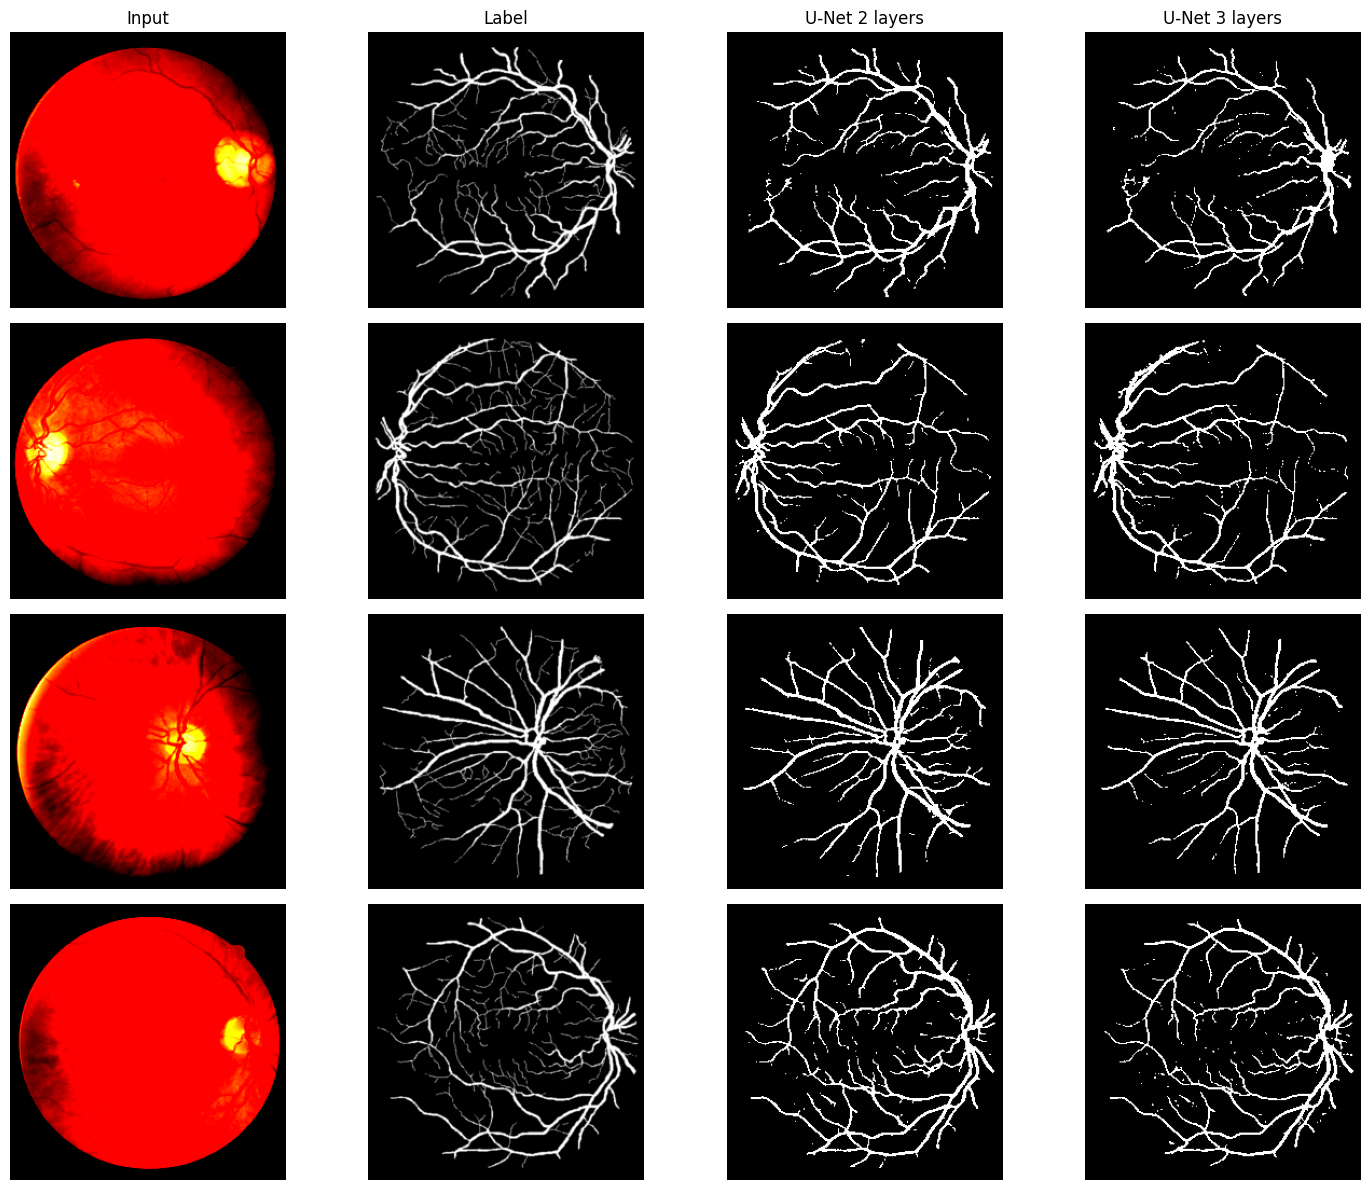

In [22]:
# test model
def test_model(model_paths_dict, test_loader, num_samples=4):
    models = {}
    for name, path in model_paths_dict.items():
        # determine blocks from name for initialization
        blocks = 2 if '2' in name else 3
        model = UNet(blocks=blocks).to(device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()
        models[name] = model

    # select a single batch
    dataiter = iter(test_loader)
    images, masks = next(dataiter)
    images = images.to(device)

    predictions = {}
    with torch.no_grad():
        for name, model in models.items():
            preds = model(images)
            predictions[name] = (preds > 0.5).float().cpu()

            # calculate metrics for the batch
            dice, iou = calculate_metrics(preds.cpu(), masks)
            print(f"{name} - Batch Dice: {dice:.4f}, IoU: {iou:.4f}")

    # Plots
    images = images.cpu()
    masks = masks.cpu()

    num_models = len(models)
    fig, axes = plt.subplots(num_samples, 2 + num_models, figsize=(15, 3 * num_samples))

    cols = ['Input', 'Label'] + list(models.keys())
    for ax, col in zip(axes[0], cols):
        ax.set_title(col)

    for i in range(num_samples):
        # Input Image
        img_disp = images[i].permute(1, 2, 0).numpy()
        # Clip to [0,1] for plots
        img_disp = np.clip(img_disp, 0, 1)
        axes[i, 0].imshow(img_disp)
        axes[i, 0].axis('off')

        # ground truth label
        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].axis('off')

        # model predictions
        for j, name in enumerate(models.keys()):
            axes[i, 2+j].imshow(predictions[name][i].squeeze(), cmap='gray')
            axes[i, 2+j].axis('off')

    plt.tight_layout()
    plt.show()

# run the test function
test_model({'U-Net 2 layers': 'best_unet_2.pth', 'U-Net 3 layers': 'best_unet_3.pth'}, test_loader)

### No Normalization

Creating unnormalized datasets...

--- Training UNNORMALIZED U-Net 2 blocks ---
Epoch 1/100 | Train Loss: 0.5337 | Val Loss: 0.6221 | Val Dice: 0.0009
  => Val Dice improved from 0.0000 to 0.0009. Saving model!
Epoch 2/100 | Train Loss: 0.4220 | Val Loss: 0.4514 | Val Dice: 0.0000
  => No improvement. Patience: 1/15
Epoch 3/100 | Train Loss: 0.3811 | Val Loss: 0.3775 | Val Dice: 0.0537
  => Val Dice improved from 0.0009 to 0.0537. Saving model!
Epoch 4/100 | Train Loss: 0.3593 | Val Loss: 0.3437 | Val Dice: 0.3847
  => Val Dice improved from 0.0537 to 0.3847. Saving model!
Epoch 5/100 | Train Loss: 0.3433 | Val Loss: 0.3316 | Val Dice: 0.4855
  => Val Dice improved from 0.3847 to 0.4855. Saving model!
Epoch 6/100 | Train Loss: 0.3334 | Val Loss: 0.3179 | Val Dice: 0.5555
  => Val Dice improved from 0.4855 to 0.5555. Saving model!
Epoch 7/100 | Train Loss: 0.3201 | Val Loss: 0.3174 | Val Dice: 0.5998
  => Val Dice improved from 0.5555 to 0.5998. Saving model!
Epoch 8/100 | Train Loss: 0

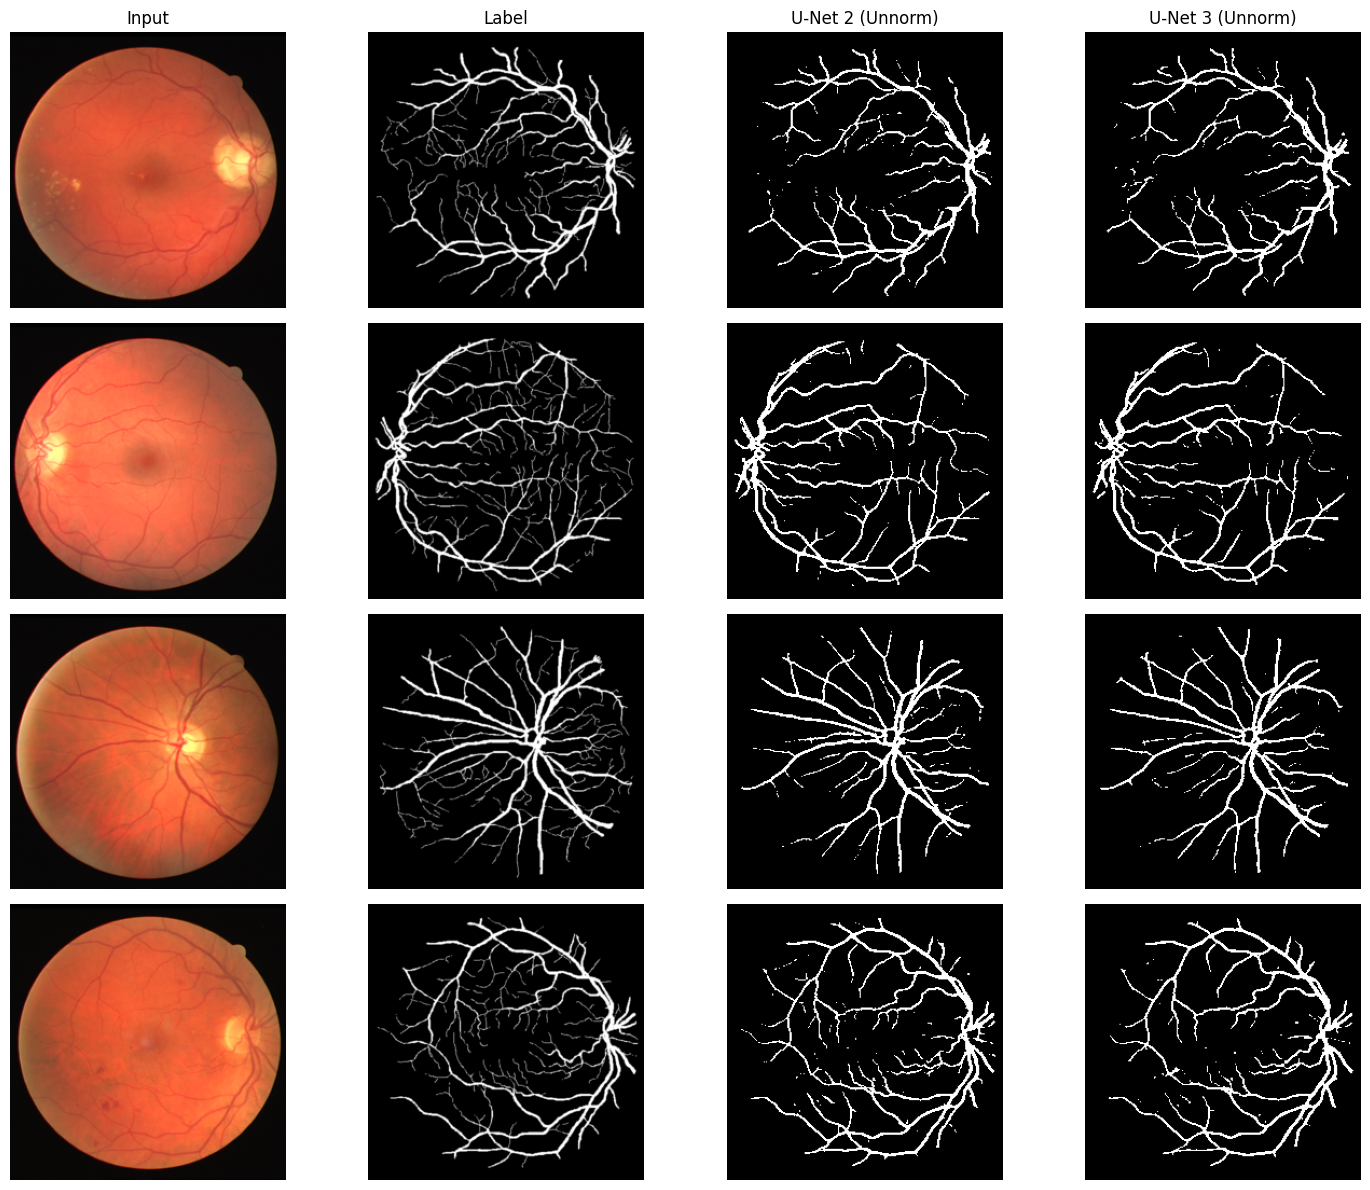

In [23]:
# transformation - with no normalization
transform_unnorm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# re-create datasets
print("Creating unnormalized datasets...")
unnorm_full_dataset = RetinaData(train_image_dir, train_mask_dir, transform=transform_unnorm)

# train-val split
unnorm_train_set, unnorm_val_set = random_split(unnorm_full_dataset, [train_size, val_size])

unnorm_train_loader = DataLoader(unnorm_train_set, batch_size=4, shuffle=True)
unnorm_val_loader = DataLoader(unnorm_val_set, batch_size=4, shuffle=False)

# re-create test loader
unnorm_test_dataset = RetinaData(test_image_dir, test_mask_dir, transform=transform_unnorm)
unnorm_test_loader = DataLoader(unnorm_test_dataset, batch_size=4, shuffle=False)

# train unnormalized U-Net 2 blocks
print("\n--- Training UNNORMALIZED U-Net 2 blocks ---")
model_2_unnorm = UNet(blocks=2).to(device)
optimizer_2_unnorm = optim.Adam(model_2_unnorm.parameters(), lr=1e-4)

model_2_unnorm = train_model(
    model=model_2_unnorm,
    train_loader=unnorm_train_loader,
    val_loader=unnorm_val_loader,
    optimizer=optimizer_2_unnorm,
    criterion=criterion,
    epochs=100,
    patience=15,
    save_path='unnorm_unet_2.pth'
)

# train unnormalized U-Net 3 blocks
print("\n--- Training UNNORMALIZED U-Net 3 blocks ---")
model_3_unnorm = UNet(blocks=3).to(device)
optimizer_3_unnorm = optim.Adam(model_3_unnorm.parameters(), lr=1e-4)

model_3_unnorm = train_model(
    model=model_3_unnorm,
    train_loader=unnorm_train_loader,
    val_loader=unnorm_val_loader,
    optimizer=optimizer_3_unnorm,
    criterion=criterion,
    epochs=100,
    patience=15,
    save_path='unnorm_unet_3.pth'
)

# metrics & visualization
print("\n--- Generating Unnormalized Test Results ---")
test_model({
    'U-Net 2 (Unnorm)': 'unnorm_unet_2.pth',
    'U-Net 3 (Unnorm)': 'unnorm_unet_3.pth'
}, unnorm_test_loader)